# Comparaison Énergie vs Résidu dans les Losses pour PINNs

## Import des bibliothèques nécessaires

In [24]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Ajouter le dossier src au path
notebook_path = Path().resolve()
ROOT = notebook_path.parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

from equations import PoissonEquation, FisherKPPStationaryEquation, AllenCahnEquation
from models import MLPModel, LinearFourierModel
from solvers import train
from data_loader import load_torch_dataset
from sampling import sample_uniform_interior
from metrics import summarize_errors

## Configuration commune

In [25]:
# Points de collocation
x_in = sample_uniform_interior(n_interior, d, device=device, dtype=dtype)

# Points de validation
x_val = ds.x[n_data_points:n_data_points+500]
u_val_true = ds.u[n_data_points:n_data_points+500]

## Fonction d'entraînement et évaluation

In [ ]:
def train_and_evaluate(model, equation, use_energy, x_in, x_data, u_data, x_val, u_val_true):
    # Entraîner
    history = train(
        model, equation, x_in,
        x_boundary=None,  # Pas de BC pour éviter NaN
        u_boundary=None,
        x_data=x_data, u_data=u_data,
        use_energy=use_energy,
        w_pde=1.0, w_bc=0.0, w_data=0.5, w_reg=0.01,  # w_bc=0.0
        lr=lr, steps=steps, print_every=print_every
    )
    
    # Évaluer
    model.eval()
    with torch.no_grad():
        u_pred = model(x_val)
    error = torch.norm(u_pred - u_val_true).item()
    
    # Vitesse de convergence : pente moyenne de la loss
    losses = np.array(history["loss_total"])
    steps_arr = np.arange(len(losses))
    if len(steps_arr) > 1:
        slope = np.polyfit(steps_arr, losses, 1)[0]
        conv_rate = -slope  # Pour residual (positive), slope négative -> positive rate; pour energy (négative), slope positive -> positive rate
    else:
        conv_rate = 0
    
    return history, error, conv_rate

## Entraînement de tous les modèles

In [27]:
results = {}
histories = {}

for eq_name, equation in equations.items():
    for model_name, model_func in models.items():
        for use_energy in [False, True]:
            loss_type = "energy" if use_energy else "residual"
            key = f"{eq_name}_{model_name}_{loss_type}"
            print(f"Entraînement: {key}")
            
            model = model_func(d)
            history, error, conv_rate = train_and_evaluate(
                model, equation, use_energy, x_in, x_data, u_data, x_val, u_val_true
            )
            
            results[key] = {"error": error, "conv_rate": conv_rate}
            histories[key] = history

Entraînement: poisson_mlp_residual
[step     1] total=1.065574e+00 pde=9.086217e-01 bc=0.000000e+00 data=3.133005e-01 reg=3.020304e-02 epoch=1/1000
[step   100] total=3.265817e-02 pde=1.339673e-02 bc=0.000000e+00 data=3.788374e-02 reg=3.195655e-02 epoch=100/1000
[step   200] total=2.099642e-02 pde=5.931113e-03 bc=0.000000e+00 data=2.948405e-02 reg=3.232834e-02 epoch=200/1000
[step   300] total=1.573629e-02 pde=2.890008e-03 bc=0.000000e+00 data=2.503898e-02 reg=3.267941e-02 epoch=300/1000
[step   400] total=1.241776e-02 pde=1.371225e-03 bc=0.000000e+00 data=2.143232e-02 reg=3.303705e-02 epoch=400/1000
[step   500] total=1.005048e-02 pde=5.850974e-04 bc=0.000000e+00 data=1.826231e-02 reg=3.342242e-02 epoch=500/1000
[step   600] total=8.429678e-03 pde=3.095862e-04 bc=0.000000e+00 data=1.556389e-02 reg=3.381470e-02 epoch=600/1000
[step   700] total=7.355575e-03 pde=3.165295e-04 bc=0.000000e+00 data=1.339480e-02 reg=3.416437e-02 epoch=700/1000
[step   800] total=6.542298e-03 pde=3.561035e-0

TypeError: cannot unpack non-iterable NoneType object

## Plot des courbes de loss

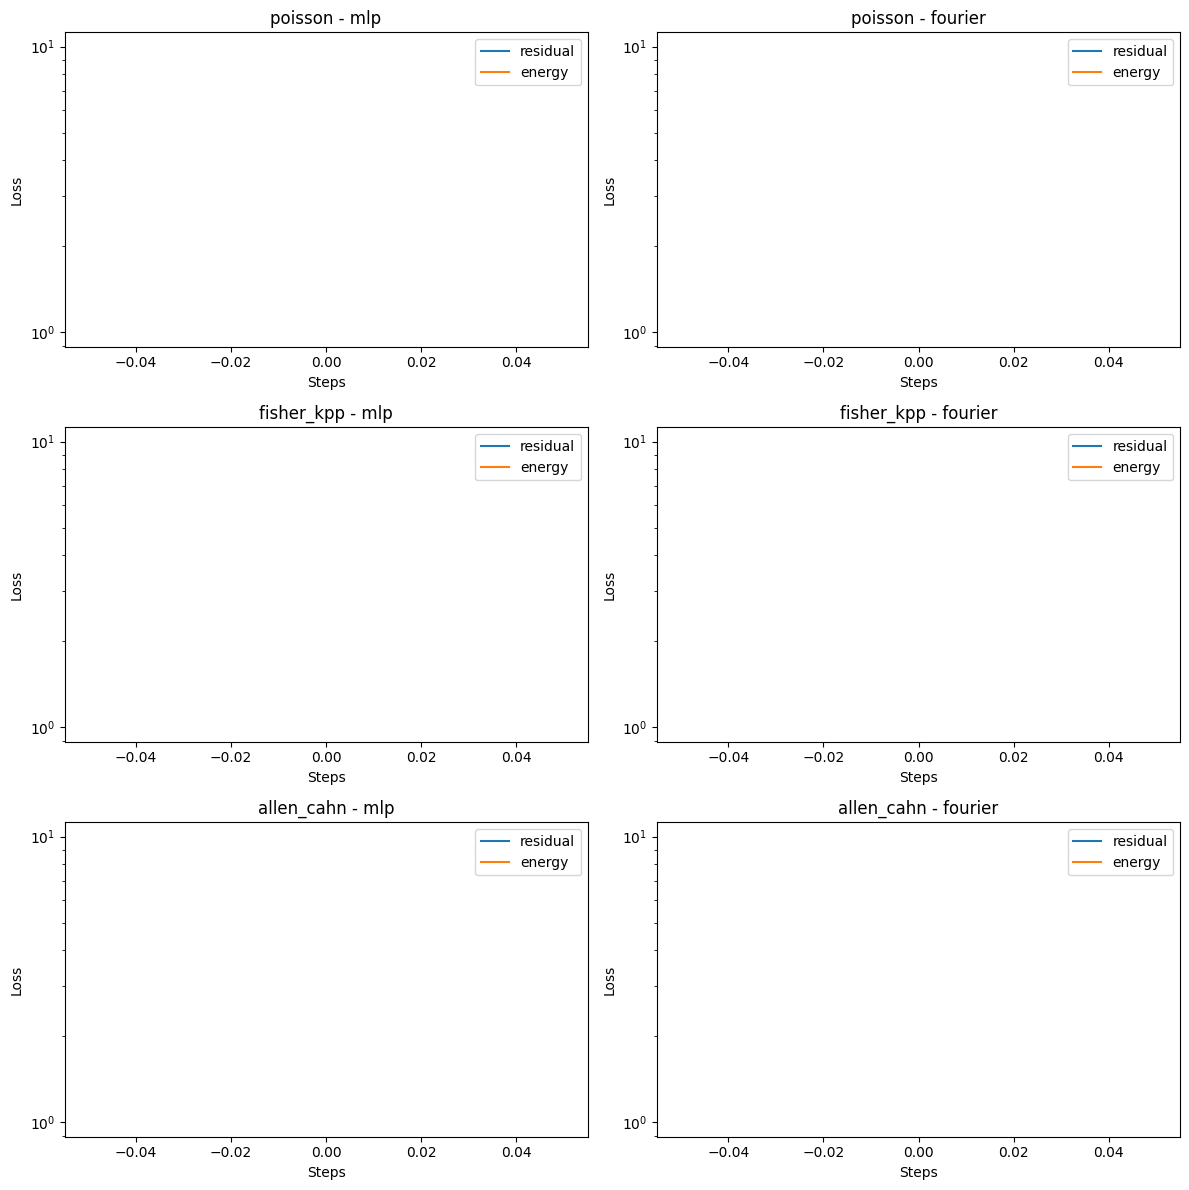

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
equations_list = list(equations.keys())
models_list = list(models.keys())

for i, eq in enumerate(equations_list):
    for j, mod in enumerate(models_list):
        ax = axes[i, j]
        for loss_type in ["residual", "energy"]:
            key = f"{eq}_{mod}_{loss_type}"
            if key in histories:
                losses = histories[key]["loss_total"]
                ax.plot(losses, label=f"{loss_type}")
        ax.set_title(f"{eq} - {mod}")
        ax.set_xlabel("Steps")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.set_yscale("log")

plt.tight_layout()
plt.show()

## Plot des vitesses de convergence

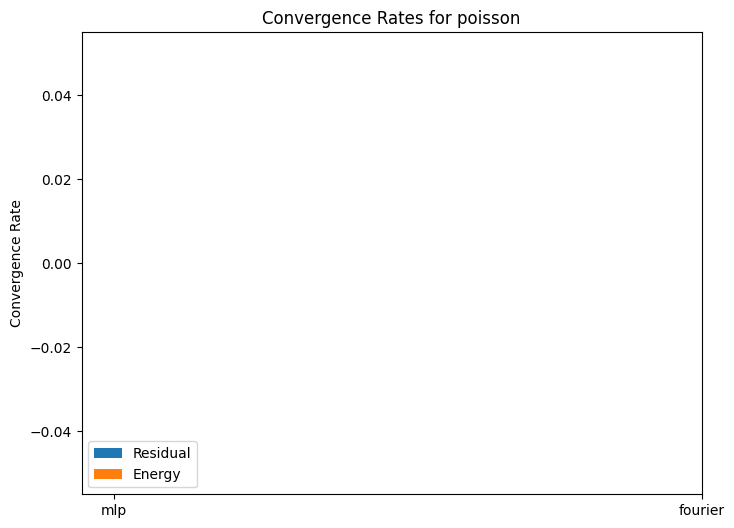

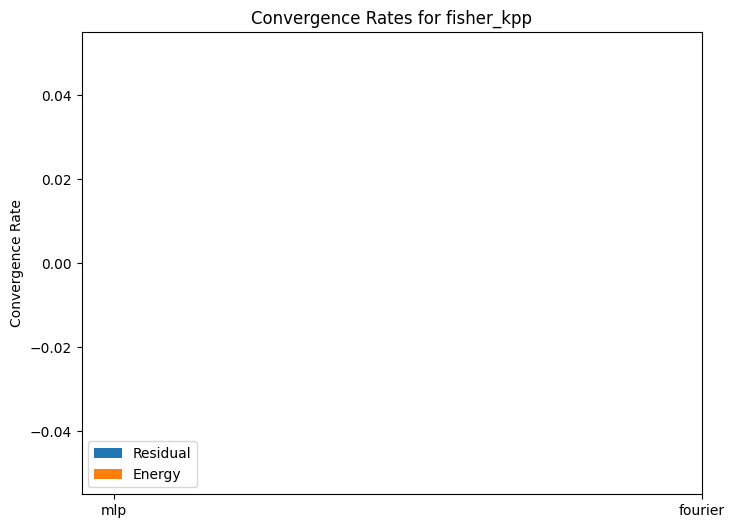

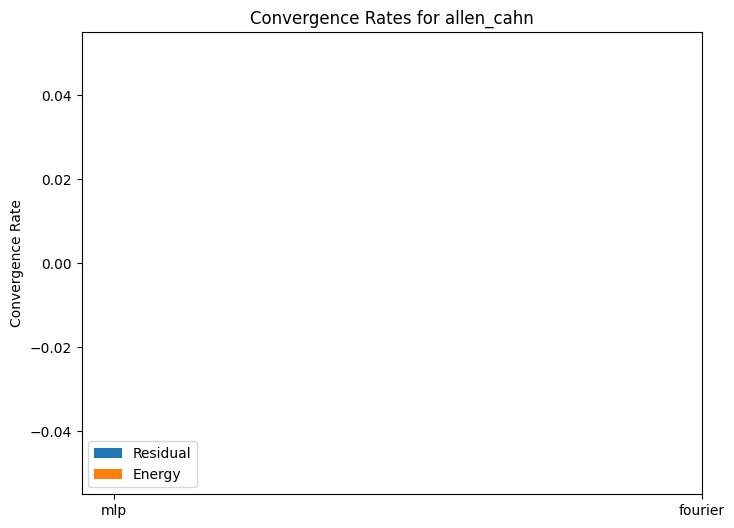

In [ ]:
conv_data = {}
for key, res in results.items():
    parts = key.rsplit("_", 2)  # Split from the right, max 2 splits
    eq, mod, loss = parts
    if eq not in conv_data:
        conv_data[eq] = {}
    if mod not in conv_data[eq]:
        conv_data[eq][mod] = {}
    conv_data[eq][mod][loss] = res["conv_rate"]

# Plot pour chaque équation
for eq in equations_list:
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(models_list))
    width = 0.35
    residual_rates = [conv_data[eq][mod]["residual"] for mod in models_list]
    energy_rates = [conv_data[eq][mod]["energy"] for mod in models_list]
    
    ax.bar(x - width/2, residual_rates, width, label="Residual")
    ax.bar(x + width/2, energy_rates, width, label="Energy")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list)
    ax.set_ylabel("Convergence Rate")
    ax.set_title(f"Convergence Rates for {eq}")
    ax.legend()
    plt.show()

## Plot des erreurs finales

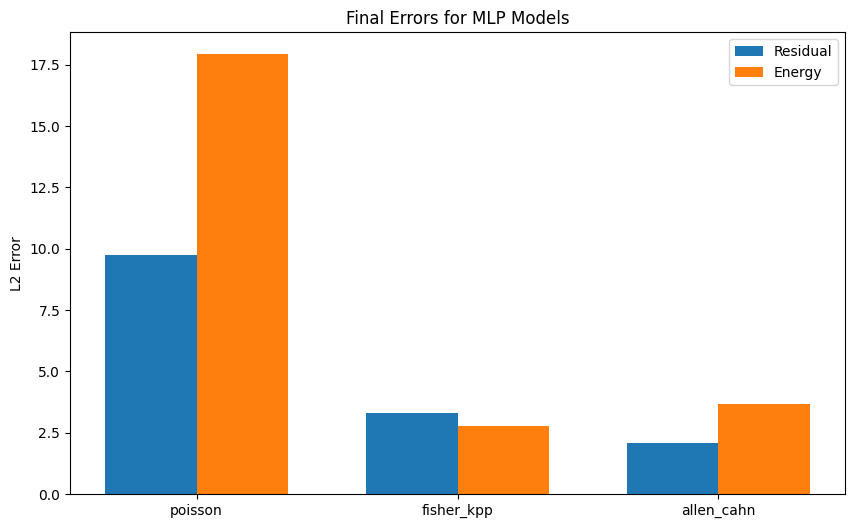

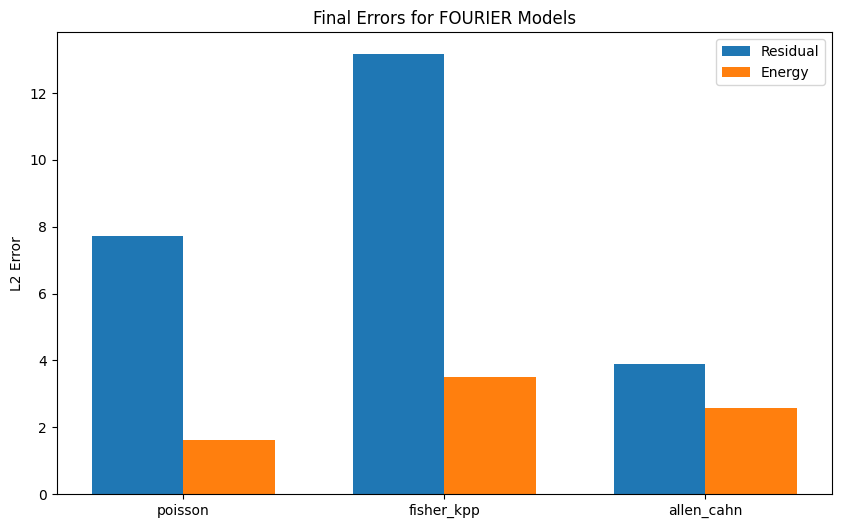

In [ ]:
# Un plot pour Fourier, un pour MLP
for mod in models_list:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(equations_list))
    width = 0.35
    residual_errors = [results[f"{eq}_{mod}_residual"]["error"] for eq in equations_list]
    energy_errors = [results[f"{eq}_{mod}_energy"]["error"] for eq in equations_list]
    
    ax.bar(x - width/2, residual_errors, width, label="Residual")
    ax.bar(x + width/2, energy_errors, width, label="Energy")
    ax.set_xticks(x)
    ax.set_xticklabels(equations_list)
    ax.set_ylabel("L2 Error")
    ax.set_title(f"Final Errors for {mod.upper()} Models")
    ax.legend()
    plt.show()